In [84]:
%pip install numpy pandas scikit-learn matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 25.4 MB/s  0:00:00m0:00:010:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 27.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 19.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 14.0 MB/s  0:00:00 eta 0:00:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [27]:
import pickle

df = None
with open("data/00012_ring2_processed.pkl", "rb") as f:
    df = pickle.load(f)

df.head()

/tmp/ipykernel_20064/701970548.py:5: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  df = pickle.load(f)


,id,start,end,fs,ir-raw,ir-standardized,ir-filtered,ir-difference,ir-welch,ir-filtered-rr,...,bvp_nn50,bvp_pnn50,resp_rr,spo2,samsung_hr,oura_hr,BP_sys,BP_dia,Experiment,Label
0,0,1.742697e+09,1.742697e+09,99.701524,"[579937, 579784, 579991, 579558, 580124, 58043...","[-0.7371179659010175, -0.751210023620453, -0.7...","[0.03760081467890073, 0.04457045040531995, 0.0...","[0.34538710948770945, 0.3572443975349071, 0.37...","[0.0006755964901876854, 0.00068124307018795, 0...","[-0.09150874938755045, -0.0868388576482947, -0...",...,1,2.380952,24.529448,98.0,None,None,85.0,63.0,Health,sitting
1,1,1.742697e+09,1.742697e+09,99.935010,"[572078, 572354, 572453, 573208, 573195, 57308...","[0.4990631958630084, 0.5798607894076976, 0.608...","[-0.0461001668537677, -0.012284576825429928, 0...","[0.6109161108131311, 0.5884055913592209, 0.558...","[0.0013708227838428292, 0.001379090127826787, ...","[0.3769013840865046, 0.3885585481475044, 0.400...",...,5,11.363636,18.397069,98.0,None,None,85.0,63.0,Health,sitting
2,2,1.742697e+09,1.742697e+09,99.949786,"[571124, 570273, 569279, 568566, 567913, 56736...","[0.3127587419554466, 0.07971555696567298, -0.1...","[-0.11780171684682562, -0.2506316733362167, -0...","[-2.2826150099469746, -2.240893086282598, -2.1...","[0.0017027899958639407, 0.0017158866707144686,...","[-0.029170245929245598, -0.039905995563454484,...",...,4,9.302326,19.931172,98.0,None,None,None,None,Health,sitting
3,3,1.742697e+09,1.742697e+09,100.122381,"[562670, 562927, 563174, 563353, 563595, 56385...","[-1.0511561405999672, -0.9870498810586342, -0....","[-0.118024257676731, -0.0928799613264786, -0.0...","[0.4764153443113916, 0.45079315177208007, 0.41...","[0.0012261603302239667, 0.0012323272422347239,...","[0.029666674247258263, 0.04400991356908477, 0....",...,0,0.0,19.931305,98.0,None,None,None,None,Health,sitting
4,4,1.742697e+09,1.742697e+09,100.005086,"[565342, 564218, 563711, 562732, 562071, 56091...","[-0.1727759540456088, -0.4690780004264144, -0....","[-0.16036486297675936, -0.29861931093288974, -...","[-2.5559366818937947, -2.5166063163710626, -2....","[0.0013432495844531104, 0.0013581919899527852,...","[-0.4075907560770166, -0.42287013997383666, -0...",...,2,4.545455,19.930453,98.233333,None,None,None,None,Health,sitting


In [72]:
import pickle
import glob
import pandas as pd
from pathlib import Path
import re

# Columns you actually need for the master dataframe
KEEP_COLS = [
    "start", "end",
    "hr", "spo2", "resp_rr",
    # "BP_sys", "BP_dia", --- data is missing for multiple subjects, leave out for now
    # "Label" --- could be useful later, but largely will use rolling windows of other features instead
]

def load_one_pkl(path):
    with open(path, "rb") as f:
        df = pickle.load(f)

    # 1. Filter keep columns
    missing = [c for c in KEEP_COLS if c not in df.columns]
    if missing:
        print(f"[warn] {path} missing columns: {missing}")

    # Select only available columns from KEEP_COLS
    available_cols = [c for c in KEEP_COLS if c in df.columns]
    out = df[available_cols].copy()

    # 2. Extract subject_id and ring using Python's 're' module
    filename = path.name if hasattr(path, "name") else str(path)
    match = re.search(r'(\d+)_ring(\d+)_processed\.pkl', filename)

    if match:
        out['id'] = int(match.group(1)) # Strips leading zeros automatically
        out['ring'] = int(match.group(2))
    else:
        print(f"[warn] Could not parse filename pattern for: {filename}")
        out['id'] = None
        out['ring'] = None

    return out

def build_master_dataframe(pkl_dir, pattern="*.pkl"):
    paths = sorted(glob.glob(str(Path(pkl_dir) / pattern)))
    if not paths:
        raise FileNotFoundError(f"No pkl files found in {pkl_dir}")

    frames = []
    for p in paths:
        try:
            frames.append(load_one_pkl(p))
        except Exception as e:
            print(f"[error] failed to load {p}: {e}")

    master = pd.concat(frames, ignore_index=True)

    # order each person's windows chronologically
    master = master.sort_values(["id", "ring", "start"]).reset_index(drop=True)

    return master

# --- usage ---
master_df = build_master_dataframe("data/")
master_df = master_df[['id', 'ring'] + KEEP_COLS]

print(master_df.shape)
print(master_df["id"].nunique(), "unique people")
print(master_df.head())

# save for reuse
master_df.to_csv('master.csv')

/tmp/ipykernel_20064/932428124.py:17: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  df = pickle.load(f)


(3422, 7)
28 unique people
   id  ring         start           end         hr       spo2    resp_rr
0   0     1  1.742608e+09  1.742608e+09  80.633333       96.0   9.089016
1   0     1  1.742608e+09  1.742608e+09       79.4       95.8  13.635623
2   0     1  1.742608e+09  1.742608e+09       78.0       96.6   10.72377
3   0     1  1.742608e+09  1.742608e+09  81.966667       96.8  12.019393
4   0     1  1.742608e+09  1.742608e+09  81.533333  96.233333  12.178545


In [73]:
df = master_df

vitals = ['hr', 'spo2', 'resp_rr']

for col in vitals:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[vitals] = (
    df.groupby(['id', 'ring'])[vitals]
    .transform(lambda group: group.interpolate(method='linear', limit_direction='both'))
)

In [77]:
import numpy as np
import pandas as pd

RANDOM_SEED = 42
TIME_UNIT = "s"  # <-- confirm: "s" (seconds) or "ms" if start/end are in milliseconds

def _rolling_slope_raw(x):
    if len(x) < 2:
        return 0.0
    return np.polyfit(np.arange(len(x)), x, 1)[0]

def add_rolling_features(df, time_windows=("30s", "120s", "600s"), time_unit=TIME_UNIT):
    df = df.sort_values(["id", "ring", "start"]).reset_index(drop=True)
    df["_start_dt"] = pd.to_datetime(df["start"], unit=time_unit)

    vitals = ["hr", "spo2", "resp_rr"]
    group_cols = ["id", "ring"]  # never mixed, even for the same id

    pieces = []
    for _, g in df.groupby(group_cols, sort=False):
        g = g.set_index("_start_dt").sort_index()
        for vital in vitals:
            for w in time_windows:
                g[f"{vital}_roll_mean_{w}"] = g[vital].rolling(w, min_periods=1).mean()
                g[f"{vital}_roll_std_{w}"] = g[vital].rolling(w, min_periods=2).std()
                g[f"{vital}_roll_slope_{w}"] = (
                    g[vital].rolling(w, min_periods=2).apply(_rolling_slope_raw, raw=True)
                )
            g[f"{vital}_dev_from_roll"] = g[vital] - g[f"{vital}_roll_mean_{time_windows[0]}"]
        pieces.append(g.reset_index())

    out = pd.concat(pieces, ignore_index=True)

    # Early rows in each id/ring session won't have a full window yet.
    # Borrow the nearest computable value within the same session, then
    # zero-fill anything still missing.
    roll_cols = [c for c in out.columns if "_roll_" in c or c.endswith("_dev_from_roll")]
    out[roll_cols] = out.groupby(group_cols)[roll_cols].transform(lambda s: s.bfill().ffill())
    out[roll_cols] = out[roll_cols].fillna(0)

    return out.drop(columns=["_start_dt"])


feat_df = add_rolling_features(df, time_windows=("30s", "120s", "600s"))
print(f"{feat_df.shape[1] - df.shape[1]} rolling feature columns added")
feat_df.head()

30 rolling feature columns added


,id,ring,start,end,hr,spo2,resp_rr,hr_roll_mean_30s,hr_roll_std_30s,hr_roll_slope_30s,...,resp_rr_roll_mean_30s,resp_rr_roll_std_30s,resp_rr_roll_slope_30s,resp_rr_roll_mean_120s,resp_rr_roll_std_120s,resp_rr_roll_slope_120s,resp_rr_roll_mean_600s,resp_rr_roll_std_600s,resp_rr_roll_slope_600s,resp_rr_dev_from_roll
0,0,1,1.742608e+09,1.742608e+09,80.633333,96.000000,9.089016,80.633333,0.872098,-1.233333,...,9.089016,3.214937,4.546607,9.089016,3.214937,4.546607,9.089016,3.214937,4.546607,0.000000
1,0,1,1.742608e+09,1.742608e+09,79.400000,95.800000,13.635623,80.016667,0.872098,-1.233333,...,11.362319,3.214937,4.546607,11.362319,3.214937,4.546607,11.362319,3.214937,4.546607,2.273304
2,0,1,1.742608e+09,1.742608e+09,78.000000,96.600000,10.723770,78.000000,2.804857,3.966667,...,10.723770,0.916144,1.295623,11.149470,2.303003,0.817377,11.149470,2.303003,0.817377,0.000000
3,0,1,1.742608e+09,1.742608e+09,81.966667,96.800000,12.019393,79.983333,2.804857,3.966667,...,11.371581,0.916144,1.295623,11.366950,1.930045,0.587928,11.366950,1.930045,0.587928,0.647812
4,0,1,1.742608e+09,1.742608e+09,81.533333,96.233333,12.178545,81.750000,0.306413,-0.433333,...,12.098969,0.112537,0.159152,11.529269,1.710422,0.456283,11.529269,1.710422,0.456283,0.079576


In [78]:
from sklearn.model_selection import GroupShuffleSplit

meta_cols = ["id", "ring", "start", "end"]
feature_cols = [c for c in feat_df.columns if c not in meta_cols]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_SEED)
train_idx, test_idx = next(gss.split(feat_df, groups=feat_df["id"]))

train_df = feat_df.iloc[train_idx].reset_index(drop=True)
test_df = feat_df.iloc[test_idx].reset_index(drop=True)

assert set(train_df["id"]).isdisjoint(set(test_df["id"])), "ID leakage between train/test!"

print(f"train: {train_df.shape}, unique ids: {train_df['id'].nunique()}")
print(f"test:  {test_df.shape}, unique ids: {test_df['id'].nunique()}")

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

train: (2934, 37), unique ids: 22
test:  (488, 37), unique ids: 6


In [79]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
iso_forest.fit(X_train)

train_df["anomaly_score"] = iso_forest.decision_function(X_train)   # higher = more normal
train_df["anomaly_pred"] = iso_forest.predict(X_train)              # -1 = anomaly, 1 = normal

test_df["anomaly_score"] = iso_forest.decision_function(X_test)
test_df["anomaly_pred"] = iso_forest.predict(X_test)

print("Train anomaly rate:", (train_df["anomaly_pred"] == -1).mean())
print("Test anomaly rate:", (test_df["anomaly_pred"] == -1).mean())

Train anomaly rate: 0.06100886162235856
Test anomaly rate: 0.06967213114754098


In [80]:
test_df.sort_values("anomaly_score").head(15)[
    ["id", "ring", "start", "hr", "spo2", "resp_rr", "anomaly_score"]
]

,id,ring,start,hr,spo2,resp_rr,anomaly_score
178,10,1,1.742652e+09,97.900000,94.700000,7.658529,-0.095523
390,22,2,1.742820e+09,78.482759,92.206897,9.182210,-0.087905
345,22,1,1.742820e+09,78.482759,92.206897,9.182145,-0.082409
177,10,1,1.742652e+09,108.100000,88.666667,6.126988,-0.072428
214,10,2,1.742652e+09,108.100000,88.666667,6.127205,-0.072041
344,22,1,1.742820e+09,85.172414,89.206897,26.017682,-0.062730
389,22,2,1.742820e+09,85.172414,89.206897,26.017588,-0.062730
341,22,1,1.742820e+09,87.000000,83.533333,19.895150,-0.058945
456,26,2,1.743057e+09,86.000000,98.633333,9.163902,-0.051983
346,22,1,1.742820e+09,73.866667,96.066667,15.312399,-0.040881


In [81]:
test_df[test_df["anomaly_pred"] == -1].groupby(["id", "ring"]).size().sort_values(ascending=False)

id  ring
22  1       8
    2       7
26  2       7
10  1       6
    2       5
9   1       1
dtype: int64

In [82]:
test_df["is_early_row"] = test_df.groupby(["id","ring"]).cumcount() < 5
test_df.groupby("is_early_row")["anomaly_pred"].apply(lambda s: (s == -1).mean())

is_early_row
False    0.076212
True     0.018182
Name: anomaly_pred, dtype: float64

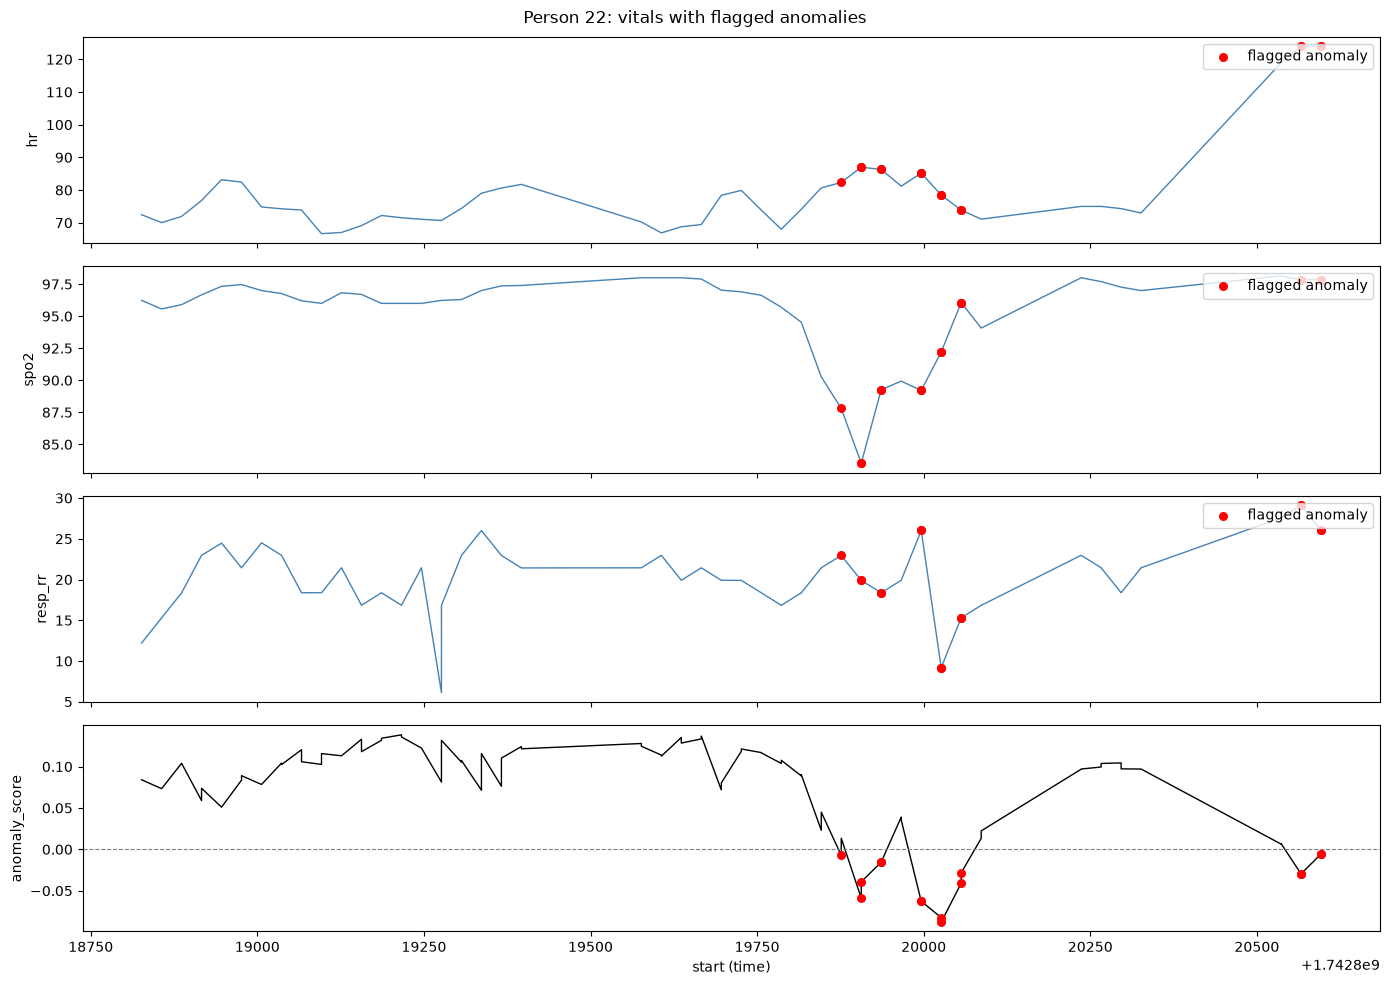

In [85]:
import matplotlib.pyplot as plt

def plot_person_anomalies(df, person_id, vitals=("hr", "spo2", "resp_rr")):
    person_df = df[df["id"] == person_id].sort_values("start")
    anomalies = person_df[person_df["anomaly_pred"] == -1]

    fig, axes = plt.subplots(len(vitals) + 1, 1, figsize=(14, 10), sharex=True)

    for ax, vital in zip(axes[:-1], vitals):
        ax.plot(person_df["start"], person_df[vital], color="steelblue", linewidth=1)
        ax.scatter(anomalies["start"], anomalies[vital], color="red", zorder=5, s=30, label="flagged anomaly")
        ax.set_ylabel(vital)
        ax.legend(loc="upper right")

    axes[-1].plot(person_df["start"], person_df["anomaly_score"], color="black", linewidth=1)
    axes[-1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
    axes[-1].scatter(anomalies["start"], anomalies["anomaly_score"], color="red", zorder=5, s=30)
    axes[-1].set_ylabel("anomaly_score")
    axes[-1].set_xlabel("start (time)")

    fig.suptitle(f"Person {person_id}: vitals with flagged anomalies")
    plt.tight_layout()
    plt.show()

plot_person_anomalies(test_df, person_id=22)